In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Load the dataset
df = pd.read_csv('fhlmc_sf2020c_loans_samp10.csv')

# Inspect dataset shape (377,995 rows x 71 columns)
print(f"Dataset Shape: {df.shape}")
print(df.info())

Dataset Shape: (377995, 71)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 377995 entries, 0 to 377994
Data columns (total 71 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            377995 non-null  int64  
 1   ENTFLAG                               377995 non-null  int64  
 2   REC_NUM                               377995 non-null  int64  
 3   UPSSTCODE                             377995 non-null  int64  
 4   MSA_CODE                              377995 non-null  int64  
 5   FIPS_CNTY_CODE                        377995 non-null  int64  
 6   CENSUS_TRACT_CODE                     377995 non-null  int64  
 7   PERCENT_MINORITY_CENTRACT             377995 non-null  float64
 8   MEDIAN_INCOME_CENTRACT                377995 non-null  int64  
 9   LOCAL_AREA_MEDIAN_INCOME              377995 non-null  int64  
 10  TRACT_LOCAL_MEDIAN_INC_RATIO          37

Top 10 States:
 col_0  Borrower_Count
STATE                
CA              58856
TX              24216
FL              21155
IL              16621
AZ              13917
OH              13506
WA              13242
MI              13064
CO              12378
VA              11858


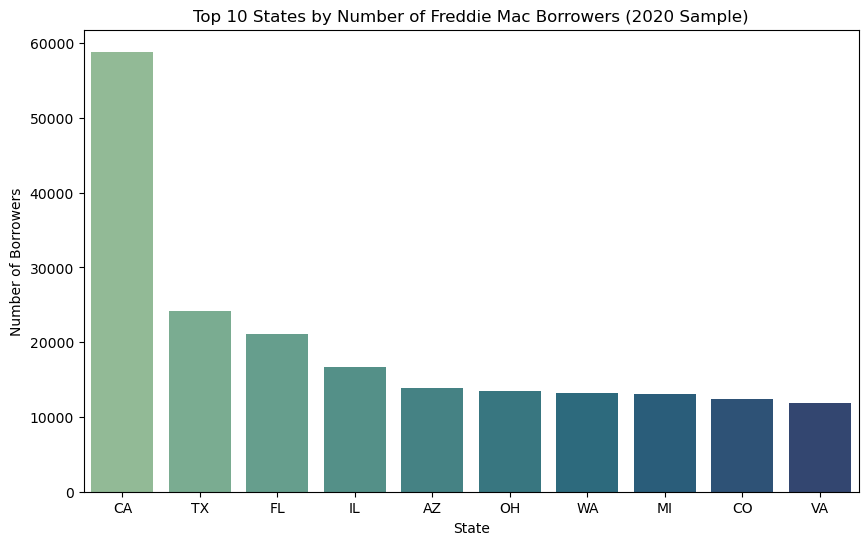

In [11]:
# Count loans per state using crosstab
state_counts = pd.crosstab(df['STATE'], columns='Borrower_Count')

# Isolate top 10 states
top_states = state_counts.sort_values(by='Borrower_Count', ascending=False).head(10)
print("Top 10 States:\n", top_states)

# Create binary indicator feature for Top 10 states (1 if in top 10, else 0)
df['TOP_10_STATE'] = df['STATE'].apply(lambda x: 1 if x in top_states.index else 0)

# Plot top 10 states bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=top_states.index, y=top_states['Borrower_Count'], hue=top_states.index, palette='crest', legend=False)
plt.title('Top 10 States by Number of Freddie Mac Borrowers (2020 Sample)')
plt.xlabel('State')
plt.ylabel('Number of Borrowers')
plt.savefig('top_10_states.png')
plt.show()

In [12]:
# Inspect raw tract income ratio distributions showing the 9999.00 flag
print("Raw Tract Income Ratio Description:")
print(df['TRACT_LOCAL_MEDIAN_INC_RATIO'].describe())

# Clean dataset by removing placeholder values (> 10)
loan_df_clean = df[df['TRACT_LOCAL_MEDIAN_INC_RATIO'] <= 10].copy()

# Confirm cleaned summary statistics
print("\nCleaned Tract Income Ratio Description:")
print(loan_df_clean['TRACT_LOCAL_MEDIAN_INC_RATIO'].describe())

Raw Tract Income Ratio Description:
count    377995.000000
mean          8.833509
std         275.862381
min           0.144100
25%           0.946800
50%           1.162800
75%           1.437700
max        9999.000000
Name: TRACT_LOCAL_MEDIAN_INC_RATIO, dtype: float64

Cleaned Tract Income Ratio Description:
count    377707.000000
mean          1.216049
std           0.398406
min           0.144100
25%           0.946700
50%           1.162400
75%           1.436900
max           3.991200
Name: TRACT_LOCAL_MEDIAN_INC_RATIO, dtype: float64


In [13]:
# Define key demographic features
features = [
    'BORROWER_GENDER',
    'BORROWER_AGE',
    'BORROWER_ANNUAL_INCOME',
    'TRACT_LOCAL_MEDIAN_INC_RATIO',
    'NOTE_AMT',
    'OCCUPANCY_CDE',
    'DEBT_TO_INCOME_RATIO'
]

# Uncleaned profiles comparison
raw_ca_tx = df[df['STATE'].isin(['CA', 'TX'])].groupby('STATE')[features].mean().T
print("Mean-Based Profiles (Raw Data):")
print(raw_ca_tx)

# Cleaned profiles comparison
clean_ca_tx = loan_df_clean[loan_df_clean['STATE'].isin(['CA', 'TX'])].groupby('STATE')[features].mean().T
print("\nMean-Based Profiles (Cleaned Data):")
print(clean_ca_tx)

Mean-Based Profiles (Raw Data):
STATE                                    CA             TX
BORROWER_GENDER                    1.500034       1.433143
BORROWER_AGE                       3.898481       3.498596
BORROWER_ANNUAL_INCOME        143480.936523  137635.199868
TRACT_LOCAL_MEDIAN_INC_RATIO       7.858471       7.140385
NOTE_AMT                      404143.757289  264093.986951
OCCUPANCY_CDE                      1.148311       1.145317
DEBT_TO_INCOME_RATIO              32.357517      30.910307

Mean-Based Profiles (Cleaned Data):
STATE                                    CA             TX
BORROWER_GENDER                    1.500026       1.433146
BORROWER_AGE                       3.898686       3.498802
BORROWER_ANNUAL_INCOME        143445.500451  137620.237997
TRACT_LOCAL_MEDIAN_INC_RATIO       1.233609       1.360448
NOTE_AMT                      404160.871500  264055.449467
OCCUPANCY_CDE                      1.148171       1.145277
DEBT_TO_INCOME_RATIO              32.356275   

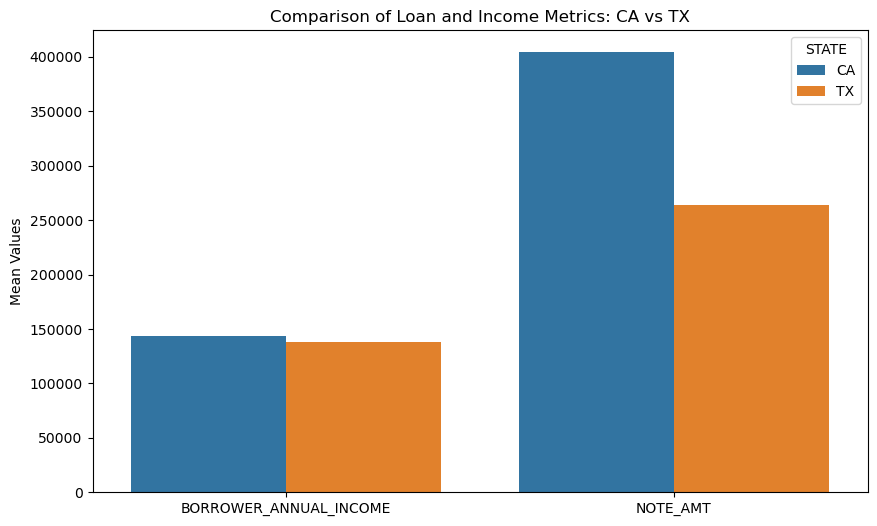

In [14]:
# Filter cleaned data for CA and TX
ca_tx_data = loan_df_clean[loan_df_clean['STATE'].isin(['CA', 'TX'])]

# Melt data for grouped bar plotting
plot_df = ca_tx_data.groupby('STATE')[['BORROWER_ANNUAL_INCOME', 'NOTE_AMT']].mean().reset_index()
plot_melted = pd.melt(plot_df, id_vars=['STATE'], value_vars=['BORROWER_ANNUAL_INCOME', 'NOTE_AMT'], 
                      var_name='Metric', value_name='Mean Values')

# Plot CA vs TX comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_melted, x='Metric', y='Mean Values', hue='STATE')
plt.title('Comparison of Loan and Income Metrics: CA vs TX')
plt.xlabel('')
plt.ylabel('Mean Values')
plt.savefig('ca_vs_tx_metrics.png')
plt.show()